In [1]:
import snapatac2 as snap
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC'
snap.__version__

'2.6.4'

## data

In [2]:
data = snap.read_dataset("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads")
# data.obs[:].to_pandas()
adata = data.to_adata()
data.close()

In [3]:
adata

AnnData object with n_obs × n_vars = 109782 × 606219
    obs: 'sample'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

In [4]:
# annotation
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/HSC/hsc_lineage.csv", index_col=0)
anno

,barcode2,sample2,cell_type_snRNA
AAACAGCCAGCAAGAT-1-0,AAACAGCCAGCAAGAT-1,GW6,APC_ventral
AAACAGCCATAAAGCA-1-0,AAACAGCCATAAAGCA-1,GW6,InN_ventral_2
AAACAGCCATCGTTCT-1-0,AAACAGCCATCGTTCT-1,GW6,NPC
AAACAGCCATTAGGTT-1-0,AAACAGCCATTAGGTT-1,GW6,Schwann
AAACCAACAAAGCTCC-1-0,AAACCAACAAAGCTCC-1,GW6,Microglia
...,...,...,...
TTTGTTGGTCACAAAT-1-7,TTTGTTGGTCACAAAT-1,GW20,OPC
TTTGTTGGTTACTAGG-1-7,TTTGTTGGTTACTAGG-1,GW20,APC_dorsal
TTTGTTGGTTAGGACC-1-7,TTTGTTGGTTAGGACC-1,GW20,NPC_proliferative
TTTGTTGGTTGCACAA-1-7,TTTGTTGGTTGCACAA-1,GW20,APC_ventral


In [6]:
adata = adata[adata.obs.index.isin(anno.index)]
adata.obs = adata.obs.join(anno)

In [7]:
adata.obs = adata.obs[['sample2', 'barcode2', 'cell_type_snRNA']]

In [8]:
adata.obs['sample2'].value_counts()

sample2
GW16    14089
GW7     10700
GW12     9146
GW10     8393
GW20     8157
GW9      7829
GW17     6832
GW6      4136
Name: count, dtype: int64

In [9]:
adata

AnnData object with n_obs × n_vars = 69282 × 606219
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

# Calculate spectral

In [10]:
snap.pp.select_features(adata, n_features=250000)
snap.tl.spectral(adata)
snap.tl.umap(adata)

2026-01-21 18:15:12 - INFO - Selected 250000 features.
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


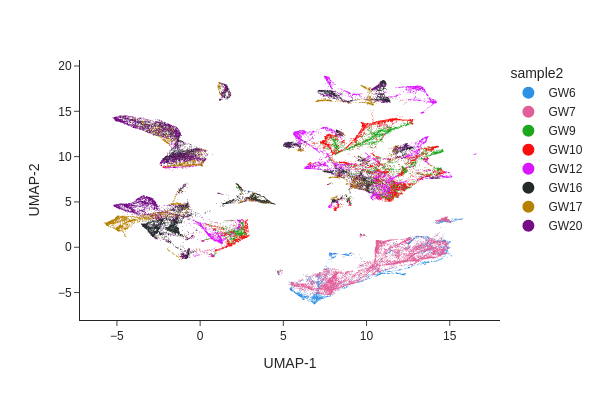

In [11]:
snap.pl.umap(adata, color="sample2", interactive=False)

# Batch correction

In [12]:
%%time
snap.pp.mnc_correct(adata, 
                    batch="sample2")

CPU times: user 8min 19s, sys: 11min 39s, total: 19min 59s
Wall time: 51.1 s


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



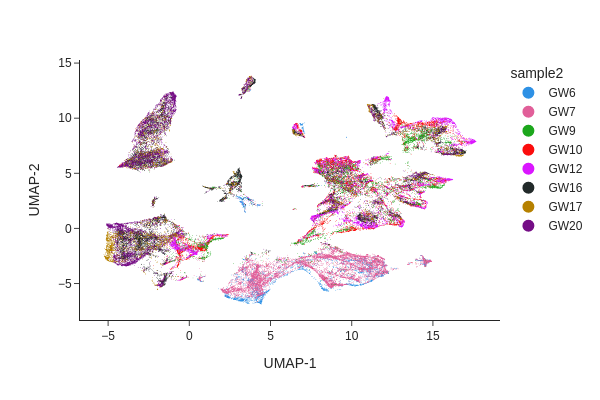

In [13]:
snap.tl.umap(adata, use_rep="X_spectral_mnn")
snap.pl.umap(adata, color="sample2", interactive=False)

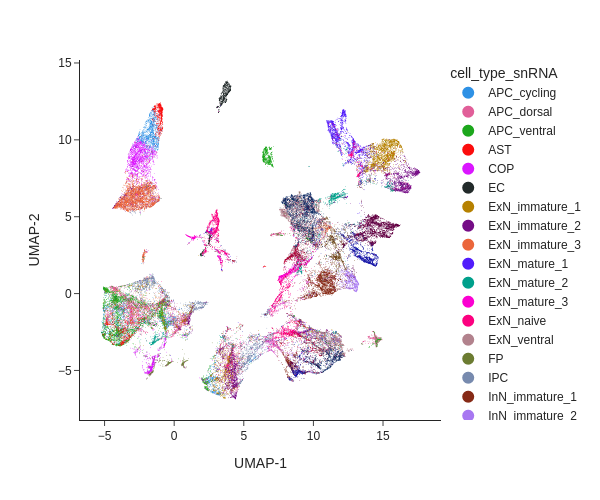

In [15]:
snap.pl.umap(adata, color="cell_type_snRNA", interactive=False, height=500)

In [16]:
adata.obs.to_csv('atac-meta.csv')

## Peak calling

In [17]:
%%time
snap.tl.macs3(adata, groupby='cell_type_snRNA', qvalue=0.01, blacklist='/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hg38-blacklist.v2.bed')

2026-01-21 18:25:11 - INFO - Exporting fragments...
2026-01-21 18:27:49 - INFO - Calling peaks...
100%|██████████| 37/37 [16:44<00:00, 27.15s/it]


CPU times: user 20min 6s, sys: 1min 20s, total: 21min 26s
Wall time: 19min 24s


In [18]:
adata

AnnData object with n_obs × n_vars = 69282 × 606219
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'AnnDataSet', 'spectral_eigenvalue', 'macs3'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap', 'X_spectral_mnn'

In [19]:
adata.obsm['fragment_paired']

<69282x3088286401 sparse matrix of type '<class 'numpy.uint32'>'
	with 690768567 stored elements in Compressed Sparse Row format>

In [20]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/hsc.h5ad')

... storing 'sample2' as categorical
... storing 'barcode2' as categorical
... storing 'cell_type_snRNA' as categorical


In [21]:
adata = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/hsc.h5ad", backed=None)
adata

AnnData object with n_obs × n_vars = 69282 × 606219
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'macs3', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_mnn', 'X_umap', 'fragment_paired'

In [22]:
%%time
peaks = snap.tl.merge_peaks(adata.uns['macs3'], snap.genome.hg38)
peaks.shape

CPU times: user 7.47 s, sys: 811 ms, total: 8.28 s
Wall time: 6.14 s


(464209, 38)

In [23]:
chrom = peaks['Peaks']
chrom.to_pandas().to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/cCREs.csv', index=False)

In [24]:
%%time
peak_mat = snap.pp.make_peak_matrix(adata, use_rep=peaks['Peaks'])
peak_mat

CPU times: user 22min 44s, sys: 27 s, total: 23min 12s
Wall time: 59.5 s


AnnData object with n_obs × n_vars = 69282 × 464209
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'

In [25]:
peak_mat.uns['reference_sequences'] = adata.uns['reference_sequences']
peak_mat.obsm['fragment_paired'] = adata.obsm['fragment_paired']

In [26]:
peak_mat.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/peak_mat.h5ad')

In [27]:
peak_mat = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/peak_mat.h5ad", backed=None)

In [28]:
%%time
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='cell_type_snRNA', pvalue=0.05)

CPU times: user 51.4 s, sys: 1.72 s, total: 53.1 s
Wall time: 53.3 s


In [29]:
marker_peaks

{'APC_cycling': Index(['chr1:1128402-1128903', 'chr1:2091940-2092441', 'chr1:2124783-2125284',
        'chr1:2138061-2138562', 'chr1:2230183-2230684', 'chr1:2432261-2432762',
        'chr1:2442592-2443093', 'chr1:2527298-2527799', 'chr1:2527973-2528474',
        'chr1:2530930-2531431',
        ...
        'chrX:153423952-153424453', 'chrX:153499854-153500355',
        'chrX:153501489-153501990', 'chrX:153521012-153521513',
        'chrX:154032720-154033221', 'chrX:154305129-154305630',
        'chrX:155230959-155231460', 'chrY:7835501-7836002',
        'chrY:13339885-13340386', 'chrY:14801033-14801534'],
       dtype='object', length=13216),
 'APC_dorsal': Index(['chr1:999926-1000427', 'chr1:1019296-1019797', 'chr1:1019798-1020299',
        'chr1:1361898-1362399', 'chr1:2527973-2528474', 'chr1:2530115-2530616',
        'chr1:2530930-2531431', 'chr1:2540774-2541275', 'chr1:2610267-2610768',
        'chr1:2789381-2789882',
        ...
        'chrX:151384729-151385230', 'chrX:151851789-1

2026-01-21 18:47:54 - WARNING - Input contains 1056046 peaks, only 50000 peaks will be plotted.


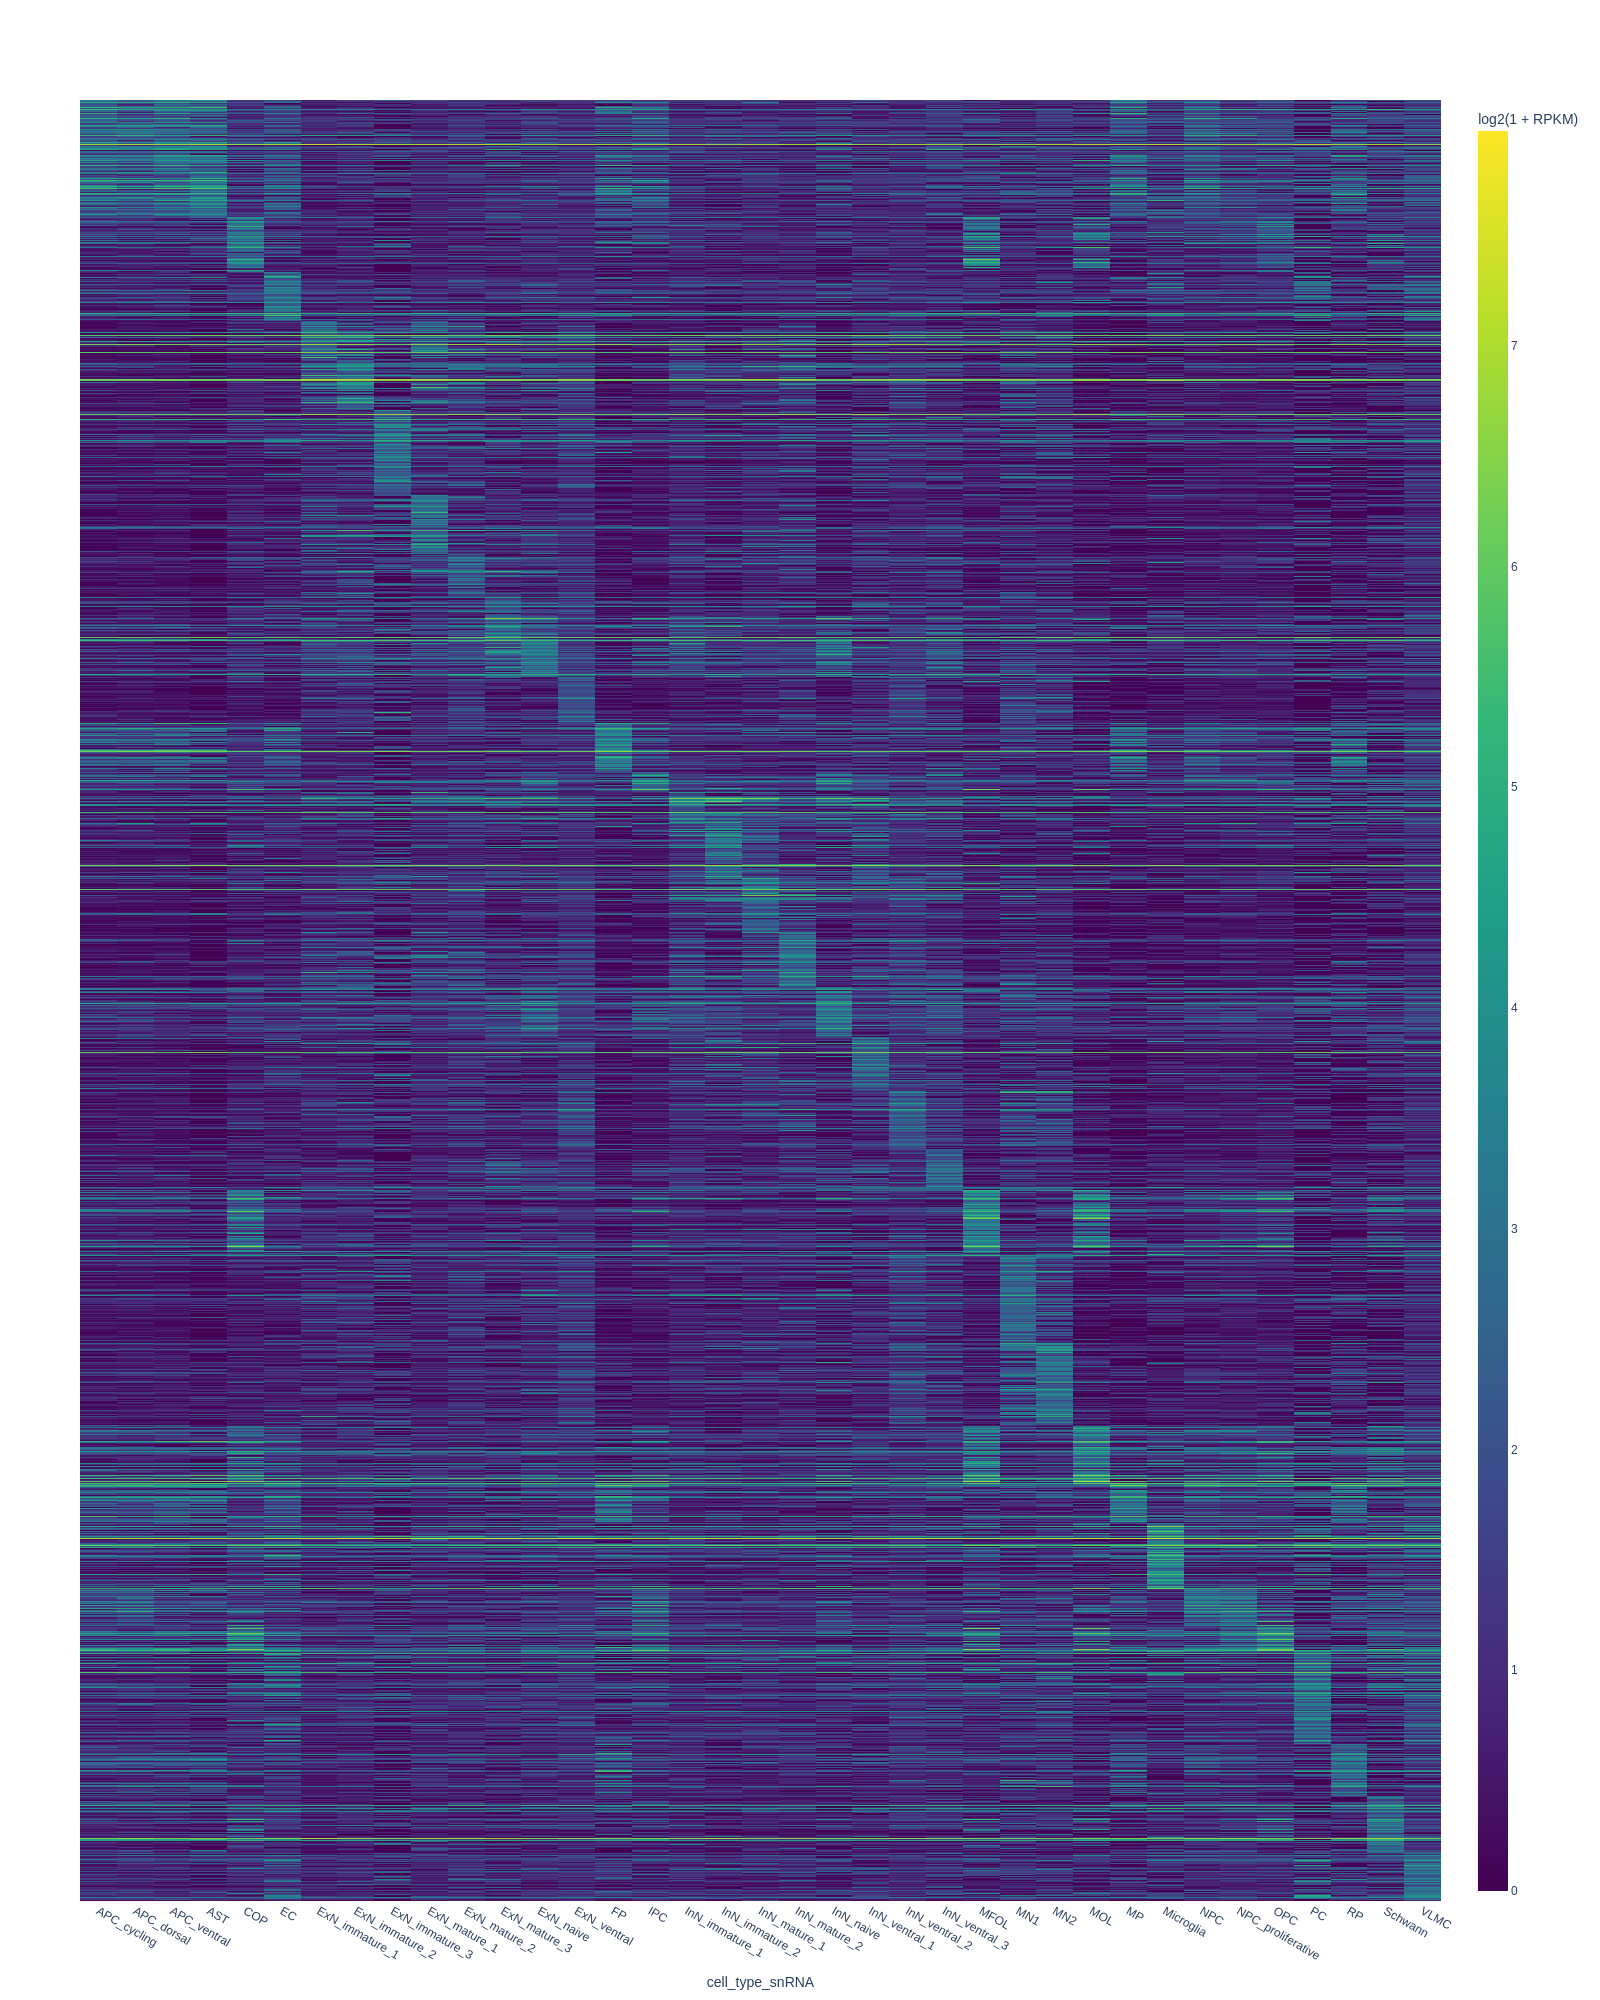

In [30]:
snap.pl.regions(peak_mat, 
                groupby='cell_type_snRNA', 
                peaks=marker_peaks, 
                width = 1600, 
                height = 2000,
                interactive=False)

In [31]:
data = []

# Iterate marker_peaks
for cell_type, peaks in marker_peaks.items():
    # Flatten peak x cell_type rows
    for peak in peaks:
        data.append([peak, cell_type])

# Build DataFrame
dar = pd.DataFrame(data, columns=['peak', 'cell_type'])

# Save CSV
dar.to_csv('hsc_marker_celltype_dar.csv', index=False)

# plot

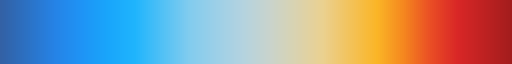

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

In [33]:
# color from meijiao
my_colors = {
    #----------Pro----------
    'NPC_proliferative' : '#D27BA1',
    'NPC' : 'darkgreen',
    'IPC' : '#D10049',

    #----------EX-----------
    'ExN_naive' : '#F2684C',
    'ExN_immature_1' : '#94191D',    
    'ExN_immature_2' : '#31A352',
    'ExN_immature_3' : '#0A0288',
    'ExN_mature_1' : '#6066AF',
    'ExN_mature_2' : '#600073',
    'ExN_mature_3' : '#3182BE',
    'ExN_ventral' : '#9594CB',
    
    #----------IN-----------
    'InN_naive' : '#FFEBB2',
    'InN_immature_1' : '#FFAA7B',
    'InN_immature_2' : '#D0696A',
    'InN_mature_1' : '#841D50',
    'InN_mature_2' : '#E63D53',
    'InN_ventral_1': '#C2C9D7',
    'InN_ventral_2': '#CE0011',
    'InN_ventral_3': '#6D006A',

    #----------MN-----------
    'MN1' : '#8E0B1B',
    'MN2' : '#AEE4EA',

    #---------Astrocyte Precursors & Astrocytes---------
    'APC_cycling' : '#D15500',
    'APC_dorsal' : '#20A6E7',
    'APC_ventral' : '#0055A9',
    'AST' : '#007854',

    #---------Oligodendrocyte Lineage---------
    'OPC' : '#5C5857',
    'COP' : '#83B3D4',
    'MFOL' : '#F0A8B1',
    'MOL' : '#FFD686',

    #---------Ependymal-----------
    'RP' : '#FBA700',
    'MP' : '#F09600',
    'FP' : '#FFDD2A',

    #---------Other-----------
    'VLMC' : '#FEFFC4',
    'EC' : '#eca9b8',
    'Schwann' : '#ba6eac',
    'PC' : '#cb909d',
    'Microglia' : '#DFB8B3'
}

groups = {
    "Pro": ["NPC_proliferative", "NPC", "IPC"],
    "EX": ["ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral"],
    "IN": ["InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3"],
    "MN": ["MN1", "MN2"],
    "APC_AST": ["APC_cycling", "APC_dorsal", "APC_ventral", "AST"],
    "OPC_OL": ["OPC", "COP", "MFOL", "MOL"],
    "Ependymal": ["RP", "MP", "FP"],
    "Other": ["Schwann", "EC", "VLMC", "PC", "Microglia"]
}

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp

# 1. Mean accessibility per cell type
def get_cluster_average(adata, groupby='celltype'):
    clusters = adata.obs[groupby].unique()
    if sp.issparse(adata.X):
        data = adata.X
    else:
        data = adata.X
        
    avg_list = []
    # Rows ordered by groups dict
    all_ordered_types = [t for g in groups.values() for t in g if t in clusters]
    
    for cluster in all_ordered_types:
        mean_val = np.array(data[adata.obs[groupby] == cluster].mean(axis=0)).flatten()
        avg_list.append(mean_val)
    
    df = pd.DataFrame(avg_list, index=all_ordered_types, columns=adata.var_names)
    return df

avg_df = get_cluster_average(peak_mat, groupby='cell_type_snRNA')

# 2. Flatten marker_peaks dict
if isinstance(marker_peaks, dict):
    # DataFrame values: use index
    # List values: extend
    flat_peaks = []
    for ct, peaks in marker_peaks.items():
        if isinstance(peaks, pd.DataFrame):
            flat_peaks.extend(peaks.index.tolist())
        else:
            flat_peaks.extend(list(peaks))
    
    # Unique preserving order
    seen = set()
    marker_peaks_list = [x for x in flat_peaks if not (x in seen or seen.add(x))]
else:
    marker_peaks_list = marker_peaks

# 3. Filter peaks
# Peaks must exist in avg_df columns
valid_peaks = [p for p in marker_peaks_list if p in avg_df.columns]
avg_df = avg_df[valid_peaks]

# 4. Z-score columns
z_df = avg_df.apply(lambda x: (x - x.mean()) / (x.std() + 1e-9), axis=0)

In [ ]:
# 1. Ordered peaks from groups
ordered_peak_list = []

# Outer loop: major groups
for group_name, subtypes in groups.items():
    # Inner loop: subtypes
    for ct in subtypes:
        if ct in marker_peaks:
            peaks = marker_peaks[ct]
            # SnapATAC2 markers often DataFrame index = peak
            if hasattr(peaks, 'index'):
                p_names = peaks.index.tolist()
            else:
                p_names = list(peaks)
            
            ordered_peak_list.extend(p_names)

# Dedupe peaks across types
from collections import OrderedDict
final_ordered_peaks = list(OrderedDict.fromkeys(ordered_peak_list))

# Intersect with matrix columns
final_ordered_peaks = [p for p in final_ordered_peaks if p in z_df.columns]

# Reorder z_df columns
z_df = z_df[final_ordered_peaks]

# Rows and columns follow group order

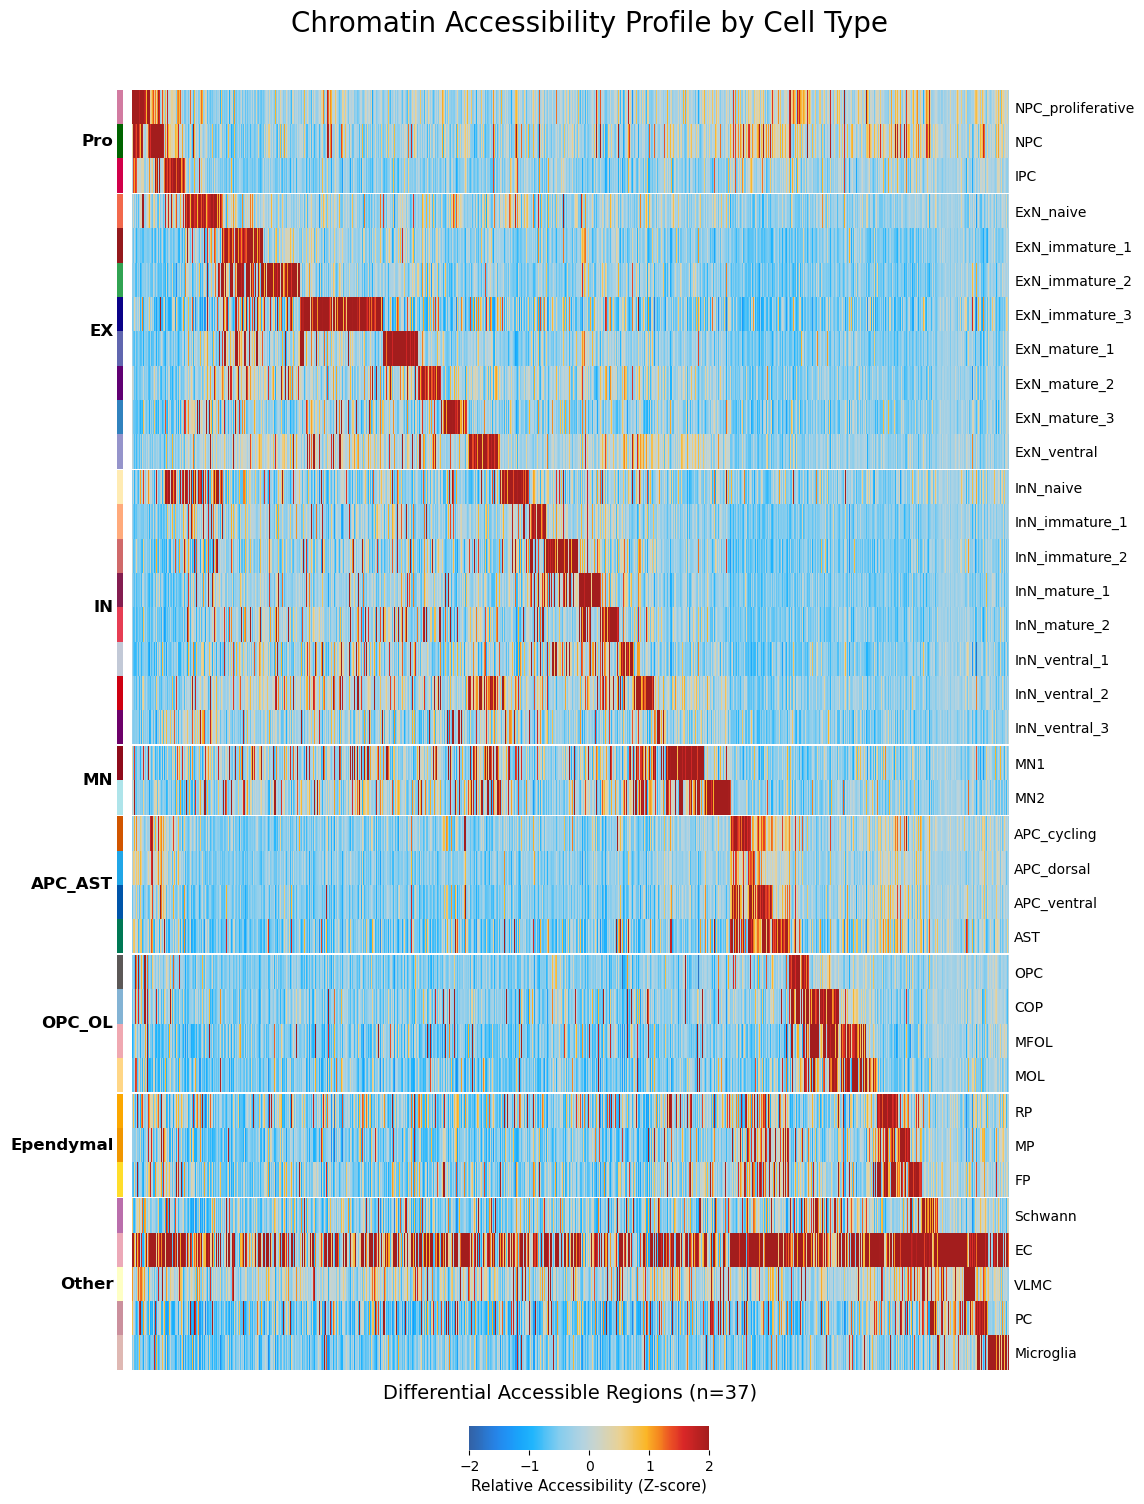

In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import seaborn as sns

# Drop types absent from data
active_groups = []
for name, types in groups.items():
    existing_types = [t for t in types if t in z_df.index]
    if existing_types:
        active_groups.append((name, existing_types))

# 2. Layout
height_ratios = [len(types) for name, types in active_groups]
fig = plt.figure(figsize=(12, 16)) 

gs = gridspec.GridSpec(len(active_groups), 2, 
                       height_ratios=height_ratios, 
                       width_ratios=[0.15, 10], # Left strip width ratio
                       hspace=0.01, wspace=0.02)

# 3. Plot each group row
all_heat_axes = []
for i, (group_name, types) in enumerate(active_groups):
    # A. Major-group labels and colors
    ax_color = fig.add_subplot(gs[i, 0])
    n_types = len(types)
    ax_color.set_ylim(n_types, 0)
    ax_color.set_xlim(0, 1)
    
    for idx, t in enumerate(types):
        # Color patch per type
        color = my_colors.get(t, "grey")
        rect = patches.Rectangle((0.6, idx), 0.4, 1, facecolor=color, edgecolor='none')
        ax_color.add_patch(rect)
    
    # Major group text
    ax_color.text(0.3, n_types/2, group_name, ha='right', va='center', 
                  fontsize=12, fontweight='bold', rotation=0)
    
    ax_color.axis('off')
    
    # B. Heatmap
    ax_heat = fig.add_subplot(gs[i, 1])
    all_heat_axes.append(ax_heat)
    
    # Subset z_df
    group_data = z_df.loc[types]
    
    sns.heatmap(
        group_data,
        ax=ax_heat,
        cmap=ATAC_cmap, 
        vmin=-2, vmax=2, # vmin/vmax for Z-scores
        xticklabels=False,
        yticklabels=True,
        cbar=False,
        rasterized=True rasterized recommended for many peaks
    )
    
    # Y tick: cell type names
    ax_heat.yaxis.tick_right()
    ax_heat.tick_params(axis='y', which='both', length=0, labelsize=10, rotation=0)
    ax_heat.set_ylabel("")
    
    # Hide spines
    for spine in ax_heat.spines.values():
        spine.set_visible(False)

# 4. Bottom x label
all_heat_axes[-1].set_xlabel(f"Differential Accessible Regions (n={len(marker_peaks)})", 
                             fontsize=14, labelpad=10)

# 5. Colorbar
cbar_ax = fig.add_axes([0.4, 0.05, 0.2, 0.015]) 
sm = plt.cm.ScalarMappable(cmap=ATAC_cmap, norm=plt.Normalize(vmin=-2, vmax=2))
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('Relative Accessibility (Z-score)', fontsize=11)
cb.outline.set_visible(False)

plt.suptitle("Chromatin Accessibility Profile by Cell Type", fontsize=20, y=0.95)
plt.subplots_adjust(bottom=0.1, top=0.9, left=0.1, right=0.85)

# Save figure
plt.savefig("Chromatin_Accessibility_Profile.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
z_df.T

,NPC_proliferative,NPC,IPC,ExN_naive,ExN_immature_1,ExN_immature_2,ExN_immature_3,ExN_mature_1,ExN_mature_2,ExN_mature_3,...,MFOL,MOL,RP,MP,FP,Schwann,EC,VLMC,PC,Microglia
chr1:1000614-1001115,1.001658,0.675415,-0.220756,-0.374501,-0.391897,-0.417078,-0.404158,-0.348585,-0.151713,-0.409642,...,-0.774332,-0.664572,0.637864,-0.370792,0.329448,-0.189374,5.436829,0.154121,0.011887,-0.727671
chr1:1085163-1085664,1.584266,0.181196,0.373176,-0.454726,-0.499667,-0.623434,0.443565,-0.209226,-0.052287,-0.071971,...,-0.676554,0.518027,-0.658378,-0.964754,-0.224172,0.836132,5.084738,0.504317,-0.786147,0.208688
chr1:2425317-2425818,2.166366,0.661744,-0.296224,-0.312177,-0.592451,-0.268306,-0.904938,-0.956623,-0.424776,-0.677102,...,0.213650,-0.096399,-0.517604,-0.616967,0.694782,-0.568920,3.777266,-0.041409,-0.391374,-0.558826
chr1:2540774-2541275,2.924740,2.704910,1.387311,-0.261723,-0.551543,-0.640833,-0.474277,-0.699732,-0.659729,-0.401095,...,-0.856587,-0.711208,1.083539,0.798399,0.235181,-0.447780,1.836290,-0.039605,-0.603287,-0.745453
chr1:3012394-3012895,2.976705,2.001019,0.921774,-0.605396,-0.872935,-0.902600,-0.737284,-0.878445,-0.684460,-0.877827,...,-0.075558,0.448157,0.543560,-0.240971,0.423784,0.356059,2.842547,-0.031141,-0.502220,-0.709134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:154763218-154763719,0.265932,0.409615,-0.315877,-0.168422,-0.452076,-0.248836,-0.905055,-0.451431,-0.368717,-0.269146,...,-0.191661,0.034525,-0.451278,0.006429,-0.114567,0.527034,5.592884,0.061133,0.526554,0.550874
chrX:154794943-154795444,-0.345332,-0.239873,-0.347272,-0.238867,-0.304896,-0.063513,0.537557,-0.123823,-0.304757,-0.110522,...,-0.292384,-0.410047,-0.410047,-0.010053,-0.410047,-0.410047,3.683602,0.051061,-0.410047,4.377847
chrX:155026629-155027130,0.213314,0.221948,-0.219044,-0.361271,-0.266524,-0.521612,-0.683572,-0.145614,0.090236,0.015454,...,-0.690763,-0.126570,-0.225236,-0.087876,0.388157,0.075584,5.717521,-0.308812,-0.356729,0.005842
chrX:155071700-155072201,0.614134,-0.076227,0.246063,-0.142424,-0.400504,-0.381855,-0.991133,-0.212621,-0.763459,-0.753264,...,0.125630,-0.676497,0.167359,-0.247704,0.035537,-0.448684,5.418343,-0.536808,0.639012,1.014794


In [38]:
# 1. peak -> cell type map
peak_to_type = {}

# Traverse groups like heatmap code
for group_name, subtypes in groups.items():
    for ct in subtypes:
        if ct in marker_peaks:
            peaks = marker_peaks[ct]
            # Peak names
            p_list = peaks.index.tolist() if hasattr(peaks, "index") else list(peaks)
            
            for p in p_list:
                # First assignment wins
                if p not in peak_to_type:
                    peak_to_type[p] = ct

# 2. Subset final_ordered_peaks
# final_ordered_peaks from prior cell
save_df = z_df[final_ordered_peaks].T 

# 3. Insert Peak_of_Group column
save_df.insert(0, 'Peak_of_Group', save_df.index.map(peak_to_type))

# 4. Optional index name
save_df.index.name = "Peak_Coord"

# 5. Save CSV
save_df.to_csv("Accessibility_with_Annotations.csv", encoding='utf_8_sig')

In [39]:
save_df

,Peak_of_Group,NPC_proliferative,NPC,IPC,ExN_naive,ExN_immature_1,ExN_immature_2,ExN_immature_3,ExN_mature_1,ExN_mature_2,...,MFOL,MOL,RP,MP,FP,Schwann,EC,VLMC,PC,Microglia
Peak_Coord,,,,,,,,,,,,,,,,,,,,,
chr1:1000614-1001115,NPC_proliferative,1.001658,0.675415,-0.220756,-0.374501,-0.391897,-0.417078,-0.404158,-0.348585,-0.151713,...,-0.774332,-0.664572,0.637864,-0.370792,0.329448,-0.189374,5.436829,0.154121,0.011887,-0.727671
chr1:1085163-1085664,NPC_proliferative,1.584266,0.181196,0.373176,-0.454726,-0.499667,-0.623434,0.443565,-0.209226,-0.052287,...,-0.676554,0.518027,-0.658378,-0.964754,-0.224172,0.836132,5.084738,0.504317,-0.786147,0.208688
chr1:2425317-2425818,NPC_proliferative,2.166366,0.661744,-0.296224,-0.312177,-0.592451,-0.268306,-0.904938,-0.956623,-0.424776,...,0.213650,-0.096399,-0.517604,-0.616967,0.694782,-0.568920,3.777266,-0.041409,-0.391374,-0.558826
chr1:2540774-2541275,NPC_proliferative,2.924740,2.704910,1.387311,-0.261723,-0.551543,-0.640833,-0.474277,-0.699732,-0.659729,...,-0.856587,-0.711208,1.083539,0.798399,0.235181,-0.447780,1.836290,-0.039605,-0.603287,-0.745453
chr1:3012394-3012895,NPC_proliferative,2.976705,2.001019,0.921774,-0.605396,-0.872935,-0.902600,-0.737284,-0.878445,-0.684460,...,-0.075558,0.448157,0.543560,-0.240971,0.423784,0.356059,2.842547,-0.031141,-0.502220,-0.709134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:154763218-154763719,Microglia,0.265932,0.409615,-0.315877,-0.168422,-0.452076,-0.248836,-0.905055,-0.451431,-0.368717,...,-0.191661,0.034525,-0.451278,0.006429,-0.114567,0.527034,5.592884,0.061133,0.526554,0.550874
chrX:154794943-154795444,Microglia,-0.345332,-0.239873,-0.347272,-0.238867,-0.304896,-0.063513,0.537557,-0.123823,-0.304757,...,-0.292384,-0.410047,-0.410047,-0.010053,-0.410047,-0.410047,3.683602,0.051061,-0.410047,4.377847
chrX:155026629-155027130,Microglia,0.213314,0.221948,-0.219044,-0.361271,-0.266524,-0.521612,-0.683572,-0.145614,0.090236,...,-0.690763,-0.126570,-0.225236,-0.087876,0.388157,0.075584,5.717521,-0.308812,-0.356729,0.005842
